# 02b RC2 Reduction — Panel Size vs Accuracy

Starting from the **Union top-500 set (1005 unique SNPs)** — the best-performing condition
in RC2 ML (~99% accuracy with SVM/LR) — this notebook asks:

> *How many SNPs can we remove while keeping accuracy high?*

SNPs are ranked by the RF + LR combined importance already computed in `02b_rc2_ml_training`.  
For each panel size, all 10 classifiers are re-evaluated with 5-fold stratified CV.

In [1]:
import sys
from pathlib import Path
_r = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts' / 'config.py').exists())
sys.path.insert(0, str(_r / 'scripts'))
from notebook_init import setup
cfg, PATHS, POPULATIONS, HARD_FILTERS, SITUATIONAL_FILTERS, ML = setup()
import os, time
print(f'Working directory: {os.getcwd()}')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

print('All imports OK')

Project root : /home/ibmelab/Projects/AISNP_Research
genomes_data : /mnt/data/aisnp_data/1000genomes/
output root  : output
Working directory: /home/ibmelab/Projects/AISNP_Research
All imports OK


## Step 1: Load Genotype Matrix and Feature Importance Ranking

In [2]:
numpy_cache  = str(PATHS.GENOTYPE_MATRIX)
cols_cache   = str(PATHS.GENOTYPE_MATRIX_COLS)
prefix_05a   = str(PATHS.outputs_dir('statistical_v2/05a_stat_training'))
imp_path     = f"{prefix_05a}_feature_importance.csv"
SAMPLES_CSV  = str(PATHS.SAMPLES_CSV)

for p in [numpy_cache, cols_cache, imp_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f'Required file missing: {p}')

# Genotype matrix
print('Loading genotype matrix...')
t0 = time.time()
data = np.load(numpy_cache)
G_raw        = data['G']                          # (n_samples, n_snps), int8
sample_names = list(data['samples'].astype(str))
with open(cols_cache) as f:
    all_snp_ids = [l.strip() for l in f]
snp_index = {s: i for i, s in enumerate(all_snp_ids)}
print(f'Matrix loaded in {time.time()-t0:.1f}s  |  shape: {G_raw.shape}')

# Population labels
samples_df = pd.read_csv(SAMPLES_CSV, header=None, names=['sample','pop','super_pop'])
pop_lookup  = dict(zip(samples_df['sample'], samples_df['pop']))
pop_labels  = np.array([pop_lookup.get(s, 'UNK') for s in sample_names])
le  = LabelEncoder()
y   = pop_labels
y_enc = le.fit_transform(y)
print(f'Classes: {le.classes_}  |  dist: {dict(zip(*np.unique(y, return_counts=True)))}')

# Feature importance ranking (already computed on union-500 = 1005 SNPs)
imp_df = pd.read_csv(imp_path).sort_values('avg_rank')
ranked_snps = imp_df['snp_id'].tolist()   # ordered best → worst
print(f'\nFeature importance ranking: {len(ranked_snps)} SNPs (union top-500 set)')
print(f'Source breakdown:')
print(imp_df['source'].value_counts().to_string())

Loading genotype matrix...
Matrix loaded in 0.6s  |  shape: (504, 614759)
Classes: ['CN' 'JPT' 'SEA']  |  dist: {np.str_('CN'): np.int64(208), np.str_('JPT'): np.int64(104), np.str_('SEA'): np.int64(192)}

Feature importance ranking: 1005 SNPs (union top-500 set)
Source breakdown:
source
afd             362
chi2+jsd        287
chi2            143
jsd              75
chi2+jsd+afd     70
jsd+afd          68


## Step 2: Define Panel Sizes and Classifiers

In [3]:
PANEL_SIZES = [25, 30, 40, 50, 55, 60, 100, 150, 200, 300, 500, 750, len(ranked_snps)]

classifiers = {
    'Random Forest':     RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost':           XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1, verbosity=0),
    'Logistic Reg':      LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', n_jobs=-1),
    'SVM (RBF)':         SVC(kernel='rbf', random_state=42),
    'SVM (Linear)':      SVC(kernel='linear', random_state=42),
    'KNN':               KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes':       GaussianNB(),
    'Grad Boosting':     GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'AdaBoost':          AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME'),
    'MLP':               MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, early_stopping=True),
}
NEEDS_SCALE = {'Logistic Reg', 'SVM (RBF)', 'SVM (Linear)', 'MLP'}
NEEDS_ENC   = {'XGBoost', 'MLP'}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy', 'f1': 'f1_weighted'}

print(f'Panel sizes to test: {PANEL_SIZES}')
print(f'Classifiers: {len(classifiers)}')
print(f'Total CV runs: {len(PANEL_SIZES) * len(classifiers)}')

Panel sizes to test: [25, 30, 40, 50, 55, 60, 100, 150, 200, 300, 500, 750, 1005]
Classifiers: 10
Total CV runs: 130


## Step 3: Run Reduction Experiment

In [4]:
all_results = []
total = len(PANEL_SIZES) * len(classifiers)
done  = 0

for panel_size in PANEL_SIZES:
    # Top-N SNPs by combined importance rank
    snp_subset = ranked_snps[:panel_size]
    idx = [snp_index[s] for s in snp_subset if s in snp_index]
    actual_n = len(idx)

    X_panel  = G_raw[:, idx].astype(np.float32)
    X_scaled = StandardScaler().fit_transform(X_panel)

    print(f'\n── Panel size {panel_size:4d}  ({actual_n} in matrix) ──')

    for clf_name, clf in classifiers.items():
        X_use = X_scaled if clf_name in NEEDS_SCALE else X_panel
        y_use = y_enc   if clf_name in NEEDS_ENC   else y

        try:
            scores = cross_validate(clf, X_use, y_use, cv=cv, scoring=scoring,
                                    return_train_score=True, n_jobs=1)
            row = {
                'panel_size':  panel_size,
                'actual_n':    actual_n,
                'classifier':  clf_name,
                'acc_mean':    scores['test_accuracy'].mean(),
                'acc_std':     scores['test_accuracy'].std(),
                'f1_mean':     scores['test_f1'].mean(),
                'train_acc':   scores['train_accuracy'].mean(),
                'overfit_gap': scores['train_accuracy'].mean() - scores['test_accuracy'].mean(),
            }
        except Exception as e:
            row = {'panel_size': panel_size, 'actual_n': actual_n,
                   'classifier': clf_name, 'acc_mean': np.nan, 'acc_std': np.nan,
                   'f1_mean': np.nan, 'train_acc': np.nan, 'overfit_gap': np.nan}

        all_results.append(row)
        done += 1
        print(f'  {clf_name:20s}  acc={row["acc_mean"]:.4f} ± {row["acc_std"]:.4f}  [{done}/{total}]')

results_df = pd.DataFrame(all_results)
print(f'\nDone. {len(results_df)} results.')


── Panel size   25  (25 in matrix) ──
  Random Forest         acc=0.8671 ± 0.0253  [1/130]
  XGBoost               acc=0.8413 ± 0.0358  [2/130]
  Logistic Reg          acc=0.8631 ± 0.0190  [3/130]
  SVM (RBF)             acc=0.8671 ± 0.0134  [4/130]
  SVM (Linear)          acc=0.8532 ± 0.0235  [5/130]
  KNN                   acc=0.7917 ± 0.0292  [6/130]
  Naive Bayes           acc=0.5436 ± 0.0389  [7/130]
  Grad Boosting         acc=0.8254 ± 0.0328  [8/130]
  AdaBoost              acc=0.8413 ± 0.0299  [9/130]
  MLP                   acc=0.7918 ± 0.0448  [10/130]

── Panel size   30  (30 in matrix) ──
  Random Forest         acc=0.8909 ± 0.0272  [11/130]
  XGBoost               acc=0.8472 ± 0.0203  [12/130]
  Logistic Reg          acc=0.8711 ± 0.0137  [13/130]
  SVM (RBF)             acc=0.8710 ± 0.0243  [14/130]
  SVM (Linear)          acc=0.8532 ± 0.0144  [15/130]
  KNN                   acc=0.8313 ± 0.0181  [16/130]
  Naive Bayes           acc=0.5515 ± 0.0370  [17/130]
  Grad Boosti

## Step 4: Summary Tables

In [5]:
# Best accuracy per panel size (max over classifiers)
best_df = (
    results_df.sort_values('acc_mean', ascending=False)
    .groupby('panel_size')
    .first()
    .reset_index()
    [['panel_size', 'actual_n', 'classifier', 'acc_mean', 'acc_std', 'f1_mean', 'overfit_gap']]
    .sort_values('panel_size')
)

# Accuracy at full set (baseline)
baseline_acc = best_df[best_df['panel_size'] == len(ranked_snps)]['acc_mean'].values[0]
best_df['acc_drop'] = baseline_acc - best_df['acc_mean']
best_df['pct_retained'] = (best_df['acc_mean'] / baseline_acc * 100).round(2)

print('Best classifier per panel size:')
print('=' * 90)
display(best_df.to_string(index=False))

# Pivot: all classifiers × panel sizes
pivot = results_df.pivot(index='classifier', columns='panel_size', values='acc_mean')
print('\nAll classifiers × panel sizes:')
display(pivot.round(4))

Best classifier per panel size:


' panel_size  actual_n    classifier  acc_mean  acc_std  f1_mean  overfit_gap  acc_drop  pct_retained\n         25        25 Random Forest  0.867109 0.025313 0.864710     0.092218  0.122970         87.58\n         30        30 Random Forest  0.890911 0.027168 0.888158     0.087264  0.099168         89.98\n         40        40     SVM (RBF)  0.908772 0.016858 0.906524     0.054525  0.081307         91.79\n         50        50     SVM (RBF)  0.944416 0.018470 0.943809     0.042191  0.045663         95.39\n         55        55     SVM (RBF)  0.948376 0.017181 0.947478     0.042197  0.041703         95.79\n         60        60     SVM (RBF)  0.950356 0.017868 0.949581     0.041208  0.039723         95.99\n        100       100     SVM (RBF)  0.978178 0.003941 0.978178     0.021822  0.011901         98.80\n        150       150     SVM (RBF)  0.990099 0.006262 0.990068     0.009901 -0.000020        100.00\n        200       200     SVM (RBF)  0.998020 0.003960 0.998021     0.001980 -0.0


All classifiers × panel sizes:


panel_size,25,30,40,50,55,60,100,150,200,300,500,750,1005
classifier,,,,,,,,,,,,,
AdaBoost,0.8413,0.8353,0.8749,0.9008,0.8968,0.8889,0.8868,0.9008,0.8790,0.8770,0.8631,0.8016,0.7976
Grad Boosting,0.8254,0.8492,0.8808,0.9166,0.9027,0.9086,0.9424,0.9524,0.9564,0.9504,0.9444,0.9325,0.9305
KNN,0.7917,0.8313,0.8452,0.8730,0.8670,0.8730,0.8750,0.9048,0.9226,0.9365,0.9484,0.9623,0.9464
Logistic Reg,0.8631,0.8711,0.8909,0.9285,0.9384,0.9424,0.9722,0.9881,0.9960,1.0000,1.0000,0.9960,0.9901
MLP,0.7918,0.8215,0.8532,0.8670,0.9266,0.9305,0.9682,0.9701,0.9802,0.9782,0.9683,0.9841,0.9702
Naive Bayes,0.5436,0.5515,0.5971,0.6665,0.6883,0.6863,0.8531,0.9225,0.9405,0.9009,0.8592,0.8353,0.8491
Random Forest,0.8671,0.8909,0.9068,0.9266,0.9325,0.9344,0.9703,0.9782,0.9682,0.9821,0.9742,0.9484,0.9602
SVM (Linear),0.8532,0.8532,0.8809,0.9305,0.9206,0.9304,0.9683,0.9841,0.9960,0.9980,0.9980,0.9960,0.9901
SVM (RBF),0.8671,0.8710,0.9088,0.9444,0.9484,0.9504,0.9782,0.9901,0.9980,1.0000,1.0000,0.9960,0.9901


## Step 5: Visualisations

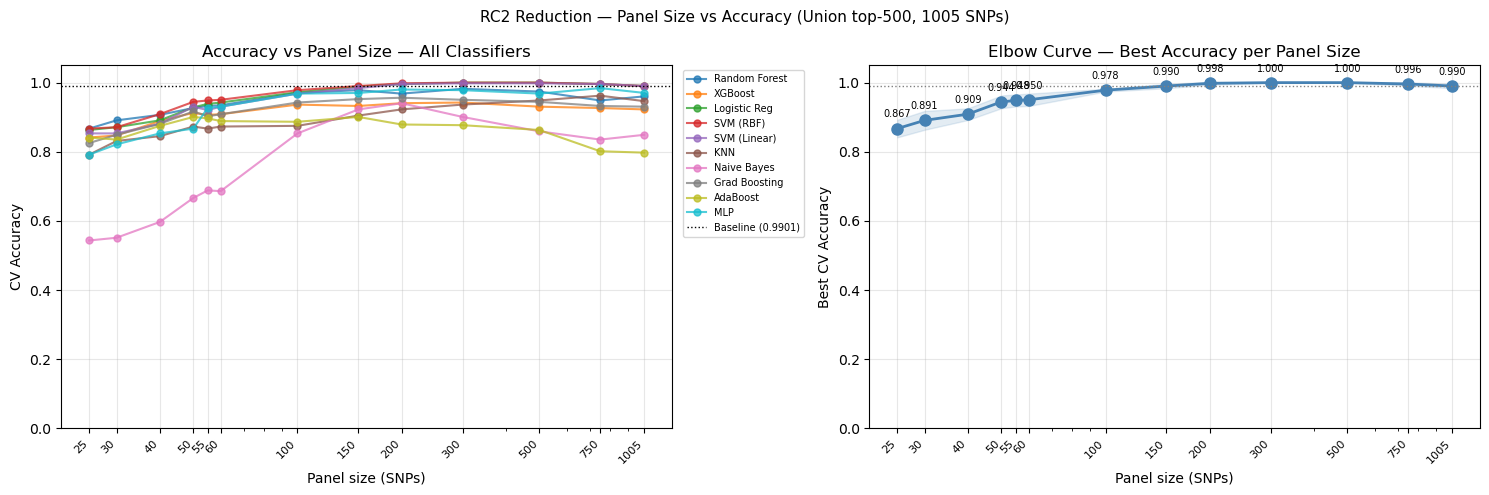

In [6]:
output_prefix = str(PATHS.outputs_dir("statistical_v2/05b_reduction"))
pop_colors    = {'CN': '#e41a1c', 'JPT': '#377eb8', 'SEA': '#4daf4a'}

# ── Elbow curve ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: all classifiers
ax = axes[0]
cmap = plt.cm.tab10(np.linspace(0, 1, len(classifiers)))
for color, clf_name in zip(cmap, classifiers):
    sub = results_df[results_df['classifier'] == clf_name].sort_values('panel_size')
    ax.plot(sub['panel_size'], sub['acc_mean'], 'o-', color=color,
            label=clf_name, alpha=0.75, linewidth=1.5, markersize=5)
ax.axhline(baseline_acc, color='black', linestyle=':', linewidth=1, label=f'Baseline ({baseline_acc:.4f})')
ax.set_xlabel('Panel size (SNPs)')
ax.set_ylabel('CV Accuracy')
ax.set_title('Accuracy vs Panel Size — All Classifiers')
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks(PANEL_SIZES)
ax.set_xticklabels(PANEL_SIZES, rotation=45, ha='right', fontsize=8)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)

# Right: best classifier per size + accuracy drop
ax2 = axes[1]
ax2.plot(best_df['panel_size'], best_df['acc_mean'], 'o-',
         color='steelblue', linewidth=2, markersize=8, label='Best acc')
ax2.fill_between(best_df['panel_size'],
                 best_df['acc_mean'] - best_df['acc_std'],
                 best_df['acc_mean'] + best_df['acc_std'],
                 alpha=0.15, color='steelblue')
ax2.axhline(baseline_acc, color='gray', linestyle=':', linewidth=1)

# Annotate each point with best classifier name + acc
for _, row in best_df.iterrows():
    ax2.annotate(f"{row['acc_mean']:.3f}",
                 (row['panel_size'], row['acc_mean']),
                 textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=7)

ax2.set_xlabel('Panel size (SNPs)')
ax2.set_ylabel('Best CV Accuracy')
ax2.set_title('Elbow Curve — Best Accuracy per Panel Size')
ax2.set_xscale('log')
ax2.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax2.set_xticks(PANEL_SIZES)
ax2.set_xticklabels(PANEL_SIZES, rotation=45, ha='right', fontsize=8)
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.suptitle('RC2 Reduction — Panel Size vs Accuracy (Union top-500, 1005 SNPs)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{output_prefix}_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

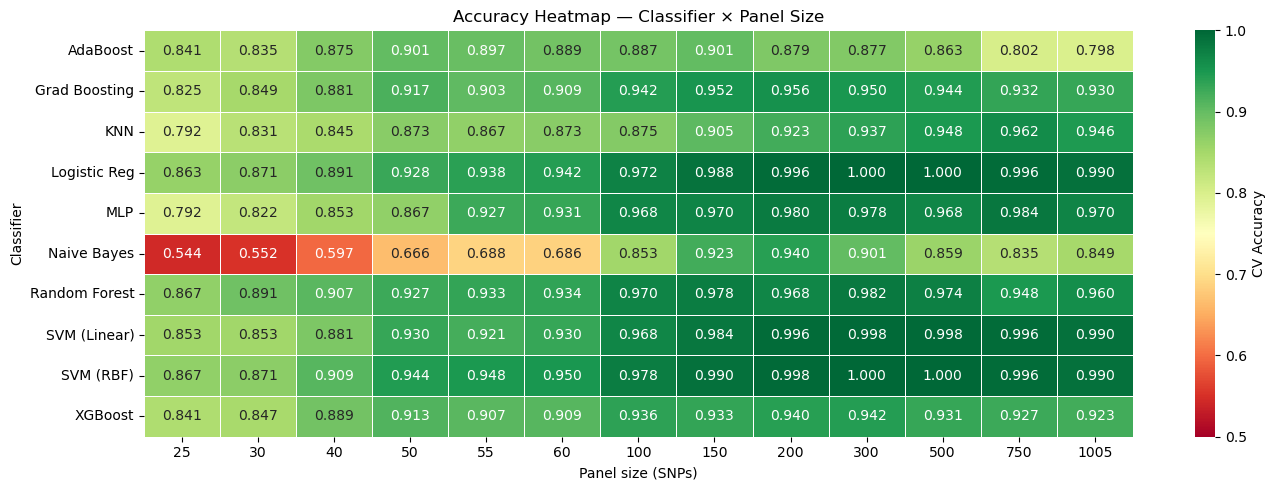

In [7]:
# ── Heatmap: classifier × panel size ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot.round(3), annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, linewidths=0.4, ax=ax,
            cbar_kws={'label': 'CV Accuracy'})
ax.set_title('Accuracy Heatmap — Classifier × Panel Size')
ax.set_xlabel('Panel size (SNPs)')
ax.set_ylabel('Classifier')
plt.tight_layout()
plt.savefig(f'{output_prefix}_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

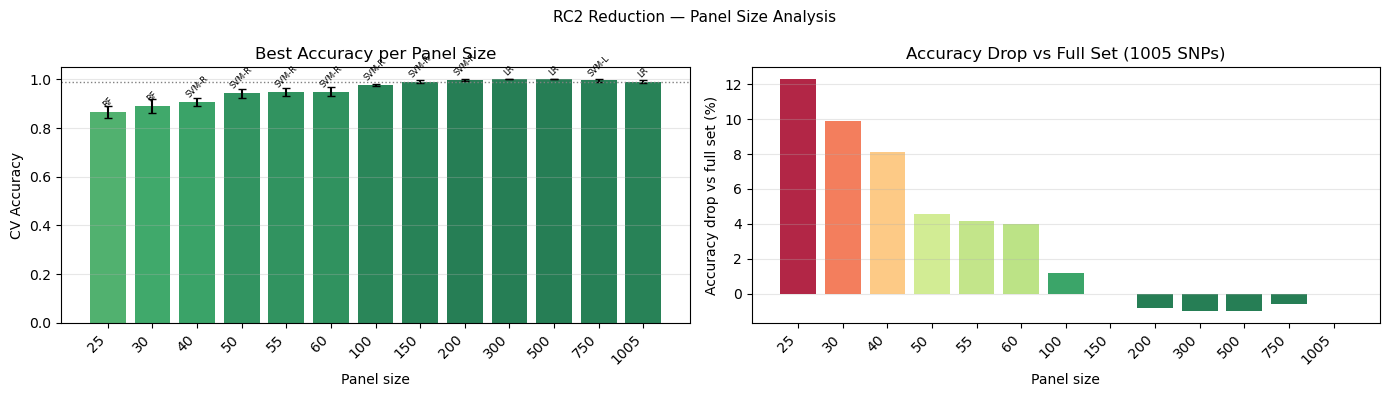

In [8]:
# ── Accuracy drop bar chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
colors = plt.cm.RdYlGn(best_df['acc_mean'].values)
bars = ax.bar(range(len(best_df)), best_df['acc_mean'], color=colors, alpha=0.85,
              yerr=best_df['acc_std'], capsize=3)
ax.set_xticks(range(len(best_df)))
ax.set_xticklabels(best_df['panel_size'].astype(str), rotation=45, ha='right')
ax.set_xlabel('Panel size')
ax.set_ylabel('CV Accuracy')
ax.set_title('Best Accuracy per Panel Size')
ax.set_ylim(0, 1.05)
ax.axhline(baseline_acc, color='gray', linestyle=':', linewidth=1)
ax.grid(alpha=0.3, axis='y')
for bar, row in zip(bars, best_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            row.classifier.replace('Logistic Reg','LR').replace('SVM (Linear)','SVM-L')
                          .replace('SVM (RBF)','SVM-R').replace('Random Forest','RF'),
            ha='center', va='bottom', fontsize=6, rotation=45)

ax2 = axes[1]
drop_colors = plt.cm.RdYlGn_r(best_df['acc_drop'].values / best_df['acc_drop'].max().clip(0.01))
ax2.bar(range(len(best_df)), best_df['acc_drop'] * 100, color=drop_colors, alpha=0.85)
ax2.set_xticks(range(len(best_df)))
ax2.set_xticklabels(best_df['panel_size'].astype(str), rotation=45, ha='right')
ax2.set_xlabel('Panel size')
ax2.set_ylabel('Accuracy drop vs full set (%)')
ax2.set_title(f'Accuracy Drop vs Full Set ({len(ranked_snps)} SNPs)')
ax2.grid(alpha=0.3, axis='y')

plt.suptitle('RC2 Reduction — Panel Size Analysis', fontsize=11)
plt.tight_layout()
plt.savefig(f'{output_prefix}_accuracy_drop.png', dpi=150, bbox_inches='tight')
plt.show()

Elbow point (acc drop ≤ 2%): 100 SNPs  (acc=0.9782, drop=0.0119)


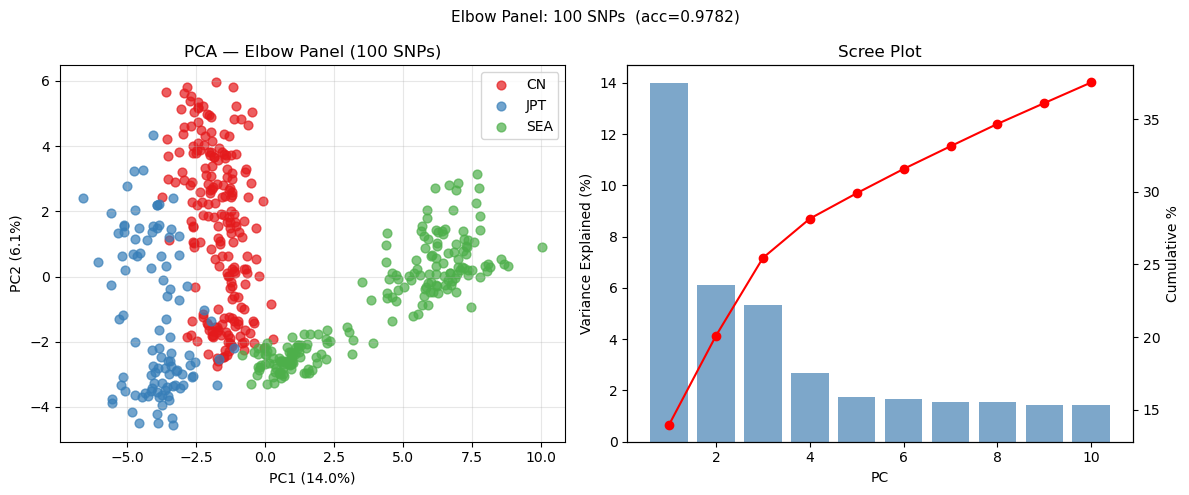

In [9]:
# ── PCA at elbow point ────────────────────────────────────────────────────────
# Use the smallest panel size that keeps accuracy within 2% of baseline
elbow_row = best_df[best_df['acc_drop'] <= 0.02].iloc[0]
elbow_n   = int(elbow_row['panel_size'])
print(f"Elbow point (acc drop ≤ 2%): {elbow_n} SNPs  "
      f"(acc={elbow_row['acc_mean']:.4f}, drop={elbow_row['acc_drop']:.4f})")

elbow_snps = ranked_snps[:elbow_n]
elbow_idx  = [snp_index[s] for s in elbow_snps if s in snp_index]
X_elbow    = G_raw[:, elbow_idx].astype(np.float32)
X_elbow_sc = StandardScaler().fit_transform(X_elbow)

n_pca = min(10, X_elbow.shape[1])
pca   = PCA(n_components=n_pca)
X_pca = pca.fit_transform(X_elbow_sc)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pop_plot_colors = {'CN': '#e41a1c', 'JPT': '#377eb8', 'SEA': '#4daf4a'}
for pop in le.classes_:
    mask = y == pop
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=pop_plot_colors.get(pop, 'gray'), label=pop, alpha=0.7, s=40)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'PCA — Elbow Panel ({elbow_n} SNPs)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(range(1, n_pca+1), pca.explained_variance_ratio_*100, color='steelblue', alpha=0.7)
ax2 = axes[1].twinx()
ax2.plot(range(1, n_pca+1), np.cumsum(pca.explained_variance_ratio_)*100, 'r-o')
ax2.set_ylabel('Cumulative %')
axes[1].set_xlabel('PC')
axes[1].set_ylabel('Variance Explained (%)')
axes[1].set_title('Scree Plot')

plt.suptitle(f'Elbow Panel: {elbow_n} SNPs  (acc={elbow_row["acc_mean"]:.4f})', fontsize=11)
plt.tight_layout()
plt.savefig(f'{output_prefix}_pca_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5b: Confusion Matrices — Best Model at Each Panel Size

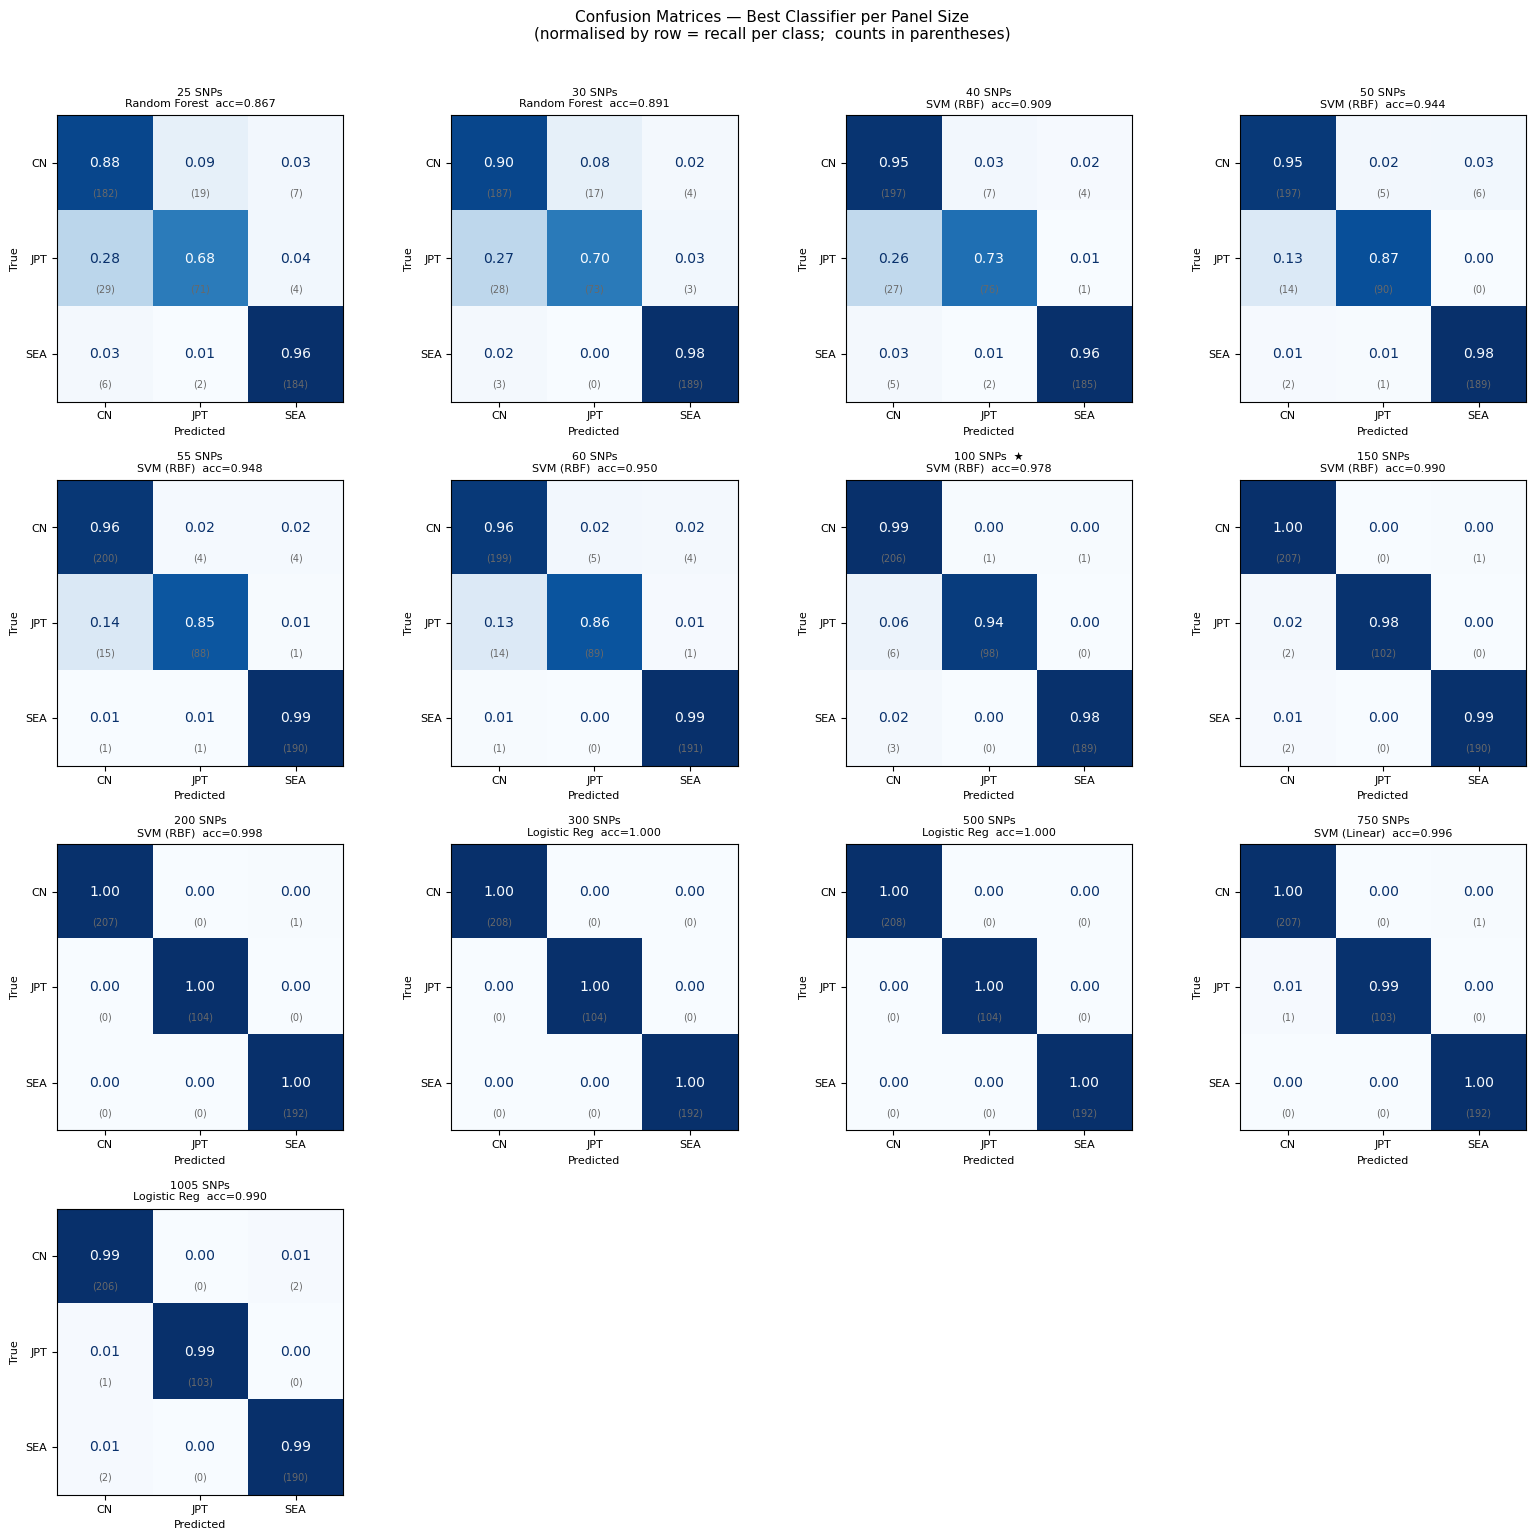

Confusion matrices saved.


In [10]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

n_sizes  = len(PANEL_SIZES)
n_cols   = 4
n_rows   = int(np.ceil(n_sizes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 4, n_rows * 3.8))
axes = axes.flatten()

class_labels = le.classes_

for ax_idx, panel_size in enumerate(PANEL_SIZES):
    ax = axes[ax_idx]

    # Best classifier for this panel size
    best_clf_name = best_df[best_df['panel_size'] == panel_size]['classifier'].values[0]
    best_acc      = best_df[best_df['panel_size'] == panel_size]['acc_mean'].values[0]
    clf           = classifiers[best_clf_name].__class__(
                        **classifiers[best_clf_name].get_params()
                    )

    # Build feature matrix
    snp_subset = ranked_snps[:panel_size]
    idx        = [snp_index[s] for s in snp_subset if s in snp_index]
    X_panel    = G_raw[:, idx].astype(np.float32)
    X_scaled   = StandardScaler().fit_transform(X_panel)

    X_use = X_scaled if best_clf_name in NEEDS_SCALE else X_panel
    y_use = y_enc   if best_clf_name in NEEDS_ENC   else y

    # OOF predictions via cross_val_predict
    y_pred = cross_val_predict(clf, X_use, y_use, cv=cv)

    # Decode if integer-encoded
    if best_clf_name in NEEDS_ENC:
        y_true_labels = le.inverse_transform(y_use)
        y_pred_labels = le.inverse_transform(y_pred)
    else:
        y_true_labels = y_use
        y_pred_labels = y_pred

    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=class_labels)

    # Normalise row-wise so colours reflect per-class recall
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')

    # Overlay raw counts in parentheses
    for i in range(len(class_labels)):
        for j in range(len(class_labels)):
            ax.text(j, i + 0.32, f'({cm[i,j]})',
                    ha='center', va='center', fontsize=7, color='dimgray')

    flag = '  ★' if panel_size == elbow_n else ''
    ax.set_title(
        f'{panel_size} SNPs{flag}\n'
        f'{best_clf_name}  acc={best_acc:.3f}',
        fontsize=8
    )
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)
    ax.tick_params(labelsize=8)

# Hide unused axes
for ax_idx in range(n_sizes, len(axes)):
    axes[ax_idx].set_visible(False)

plt.suptitle(
    'Confusion Matrices — Best Classifier per Panel Size\n'
    '(normalised by row = recall per class;  counts in parentheses)',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig(f'{output_prefix}_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrices saved.')

## Step 6: Save Results and Final SNP Panel

In [11]:
results_df.to_csv(f'{output_prefix}_all_cv_results.csv', index=False)
print(f'Saved: {output_prefix}_all_cv_results.csv')

best_df.to_csv(f'{output_prefix}_best_per_size.csv', index=False)
print(f'Saved: {output_prefix}_best_per_size.csv')

# Save ranked SNP list for every tested panel size
for panel_size in PANEL_SIZES:
    snp_subset = ranked_snps[:panel_size]
    out = f'{output_prefix}_panel_{panel_size}_snps.txt'
    with open(out, 'w') as f:
        f.write('\n'.join(snp_subset))
    print(f'Saved: {out}  ({len(snp_subset)} SNPs)')

# Also save source annotation for the elbow panel
elbow_imp = imp_df[imp_df['snp_id'].isin(ranked_snps[:elbow_n])].copy()
elbow_imp.to_csv(f'{output_prefix}_elbow_panel_{elbow_n}_annotated.csv', index=False)
print(f'\nElbow panel ({elbow_n} SNPs) with source annotation saved.')

Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/05b_reduction_all_cv_results.csv
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/05b_reduction_best_per_size.csv
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/05b_reduction_panel_25_snps.txt  (25 SNPs)
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/05b_reduction_panel_30_snps.txt  (30 SNPs)
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/05b_reduction_panel_40_snps.txt  (40 SNPs)
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/05b_reduction_panel_50_snps.txt  (50 SNPs)
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/05b_reduction_panel_55_snps.txt  (55 SNPs)
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/05b_reduction_panel_60_snps.txt  (60 SNPs)
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/05b_reduction_panel_100_snps.txt  (100 SNPs)
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/05

## Summary

In [12]:
print('=' * 70)
print('02b RC2 REDUCTION SUMMARY')
print('=' * 70)
print(f'\nStarting set : Union top-500 = {len(ranked_snps)} unique SNPs')
print(f'Baseline acc : {baseline_acc:.4f} (best classifier on full set)')
print(f'Panel sizes  : {PANEL_SIZES}')
print()

print(f'{"Size":>6}  {"Acc":>7}  {"Drop":>7}  {"Ret%":>6}  Best Classifier')
print('-' * 60)
for _, row in best_df.iterrows():
    flag = '  ← elbow' if row['panel_size'] == elbow_n else ''
    print(f"{int(row['panel_size']):>6}  {row['acc_mean']:>7.4f}  "
          f"{row['acc_drop']:>7.4f}  {row['pct_retained']:>5.1f}%  "
          f"{row['classifier']}{flag}")

print(f'\nElbow point (≤2% drop): {elbow_n} SNPs  '
      f'acc={elbow_row["acc_mean"]:.4f}  '
      f'drop={elbow_row["acc_drop"]:.4f}')

print(f'\nTop-10 SNPs in elbow panel (by RF+LR rank):')
for i, row in imp_df.head(10).iterrows():
    in_elbow = '✓' if row['snp_id'] in set(ranked_snps[:elbow_n]) else ' '
    print(f'  [{in_elbow}] {row["snp_id"]:35s}  [{row["source"]}]')

print(f'\nOutput files:')
print(f'  {output_prefix}_all_cv_results.csv')
print(f'  {output_prefix}_best_per_size.csv')
print(f'  {output_prefix}_panel_{{N}}_snps.txt  (one per panel size)')
print(f'  {output_prefix}_elbow_panel_{elbow_n}_annotated.csv')
print(f'\nNext: 05_model_evaluation with elbow panel SNPs.')

02b RC2 REDUCTION SUMMARY

Starting set : Union top-500 = 1005 unique SNPs
Baseline acc : 0.9901 (best classifier on full set)
Panel sizes  : [25, 30, 40, 50, 55, 60, 100, 150, 200, 300, 500, 750, 1005]

  Size      Acc     Drop    Ret%  Best Classifier
------------------------------------------------------------
    25   0.8671   0.1230   87.6%  Random Forest
    30   0.8909   0.0992   90.0%  Random Forest
    40   0.9088   0.0813   91.8%  SVM (RBF)
    50   0.9444   0.0457   95.4%  SVM (RBF)
    55   0.9484   0.0417   95.8%  SVM (RBF)
    60   0.9504   0.0397   96.0%  SVM (RBF)
   100   0.9782   0.0119   98.8%  SVM (RBF)  ← elbow
   150   0.9901  -0.0000  100.0%  SVM (RBF)
   200   0.9980  -0.0079  100.8%  SVM (RBF)
   300   1.0000  -0.0099  101.0%  Logistic Reg
   500   1.0000  -0.0099  101.0%  Logistic Reg
   750   0.9960  -0.0060  100.6%  SVM (Linear)
  1005   0.9901   0.0000  100.0%  Logistic Reg

Elbow point (≤2% drop): 100 SNPs  acc=0.9782  drop=0.0119

Top-10 SNPs in elbow pan